# BombCell on a SpikeInterface SortingAnalyzer

This demo runs the full BombCell quality control pipeline on a
[SpikeInterface](https://spikeinterface.readthedocs.io/) `SortingAnalyzer`, rather than on a
Kilosort output folder (for that, see the other demos in this folder).

It runs end to end on simulated data, so you can execute it as-is with no data and no paths to
edit. To use your own recording, replace the "Simulated data" cell with
`analyzer = si.load_sorting_analyzer("/path/to/your/sorting_analyzer.zarr")`.

**Requirements**: SpikeInterface is an optional dependency of bombcell:

```
pip install "bombcell[spikeinterface]"
```

**How the pieces fit together**

- `bombcell.run_bombcell_qc` (this repo) decides which quality metrics to compute, computes the
  extensions they depend on, runs the labeling, plots and saves. It carries the BombCell-flavored
  defaults.
- `spikeinterface.curation.bombcell_label_units` (SpikeInterface) is the labeler itself: it reads
  metrics and applies thresholds. It computes nothing.

In [1]:
import warnings
from pathlib import Path
from pprint import pprint

import spikeinterface.full as si
import spikeinterface.curation as sc
import spikeinterface.widgets as sw

import bombcell

✅ ipywidgets available - interactive GUI ready


## Simulated data

We generate a small ground-truth recording and build a `SortingAnalyzer` from it. The pipeline
needs `template_metrics` computed up front (that is where the waveform-shape metrics used for
noise and non-somatic labeling come from). Everything else it computes itself.

Replace this cell with `si.load_sorting_analyzer(...)` to use your own data.

In [2]:
recording, sorting = si.generate_ground_truth_recording(
    num_channels=8,
    num_units=15,
    durations=[300.0],
    seed=0,
)

analyzer = si.create_sorting_analyzer(sorting, recording, sparse=True)
analyzer.compute({"random_spikes": {"seed": 0}, "noise_levels": {}, "templates": {}})
analyzer.compute("template_metrics", include_multi_channel_metrics=True)

print(f"{analyzer.unit_ids.size} units")
print("extensions:", sorted(analyzer.get_loaded_extension_names()))

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

estimate_templates_with_accumulator (no parallelization):   0%|          | 0/300 [00:00<?, ?it/s]

/Users/jf5479/Dropbox/Python/spikeinterface/src/spikeinterface/metrics/template/template_metrics.py:314: UserWarning: With less than 10 channels, multi-channel metrics might not be reliable.
  warnings.warn(


15 units
extensions: ['noise_levels', 'random_spikes', 'template_metrics', 'templates']


## QC parameters

`get_default_qc_params()` returns the knobs controlling *which* metrics get computed and how.
The pipeline computes prerequisite extensions for you: `spike_amplitudes` for `amplitude_median`,
`spike_locations` for drift, `amplitude_scalings` for `amplitude_cutoff`, and principal
components for the distance metrics.

In [3]:
qc_params = bombcell.get_default_qc_params()

# --- Metrics to compute ---
qc_params["compute_amplitude_cutoff"] = True   # estimate missing spikes
qc_params["compute_drift"] = True              # position changes over time
qc_params["compute_distance_metrics"] = False  # isolation distance & L-ratio: slow, and not drift-robust.
                                               # Recommended True for stable/chronic recordings.

# --- Labeling options ---
# The refractory-period-violation method is NOT set here: it is chosen by which key you put in
# thresholds["mua"] below. That single entry picks both the metric and its threshold.
qc_params["split_non_somatic"] = False    # if True, non-somatic units split into good/mua subcategories
qc_params["compute_valid_periods"] = False  # restrict metrics to each unit's stable periods

# --- Metric parameters ---
qc_params["presence_ratio_bin_duration_s"] = 60  # bin size (s) for "does the unit fire throughout?"
qc_params["drift_interval_s"] = 60               # time bin (s) for position over time
qc_params["drift_min_spikes"] = 100              # min spikes per bin to estimate position

# --- Plotting ---
qc_params["plot_histograms"] = True
qc_params["plot_waveforms"] = True
qc_params["plot_upset"] = True

pprint(qc_params)

{'compute_amplitude_cutoff': True,
 'compute_distance_metrics': False,
 'compute_drift': True,
 'compute_valid_periods': False,
 'drift_interval_s': 60,
 'drift_min_spikes': 100,
 'figsize_histograms': (15, 10),
 'plot_histograms': True,
 'plot_upset': True,
 'plot_waveforms': True,
 'presence_ratio_bin_duration_s': 60,
 'split_non_somatic': False,
 'waveform_ylims': (-300, 100)}


To bypass the `compute_*` flags entirely and name the metrics yourself:

```python
qc_params["metric_names"] = [
    "amplitude_median", "snr", "num_spikes", "presence_ratio",
    "firing_rate", "sliding_rp_violation", "drift",
]
qc_params["metric_params"] = {"drift": {"interval_s": 30}}
```

## Classification thresholds

Each threshold is `{"greater": min, "less": max}` and a unit passes when `min < value < max`.
Use `None` to disable a bound, and add `"abs": True` to compare on absolute value.

There are three sections:

- **noise** — waveform quality. Failing *any* threshold means `noise`.
- **mua** — spike quality, applied only to units that passed noise. Failing *any* means `mua`.
- **non-somatic** — waveform shape, used to detect axonal/dendritic units.

**Refractory-period violations**: `thresholds["mua"]` should contain exactly one of
`sliding_rp_violation` or `rp_contamination`. That one entry selects both which metric gets
computed and the threshold applied to it.

In [4]:
thresholds = sc.bombcell_get_default_thresholds()
pprint(thresholds)

{'mua': {'amplitude_cutoff': {'greater': None, 'less': 0.2},
         'amplitude_median': {'abs': True, 'greater': 30, 'less': None},
         'drift_ptp': {'greater': None, 'less': 100},
         'isolation_distance': {'greater': 20, 'less': None},
         'l_ratio': {'greater': None, 'less': 0.3},
         'num_spikes': {'greater': 300, 'less': None},
         'presence_ratio': {'greater': 0.7, 'less': None},
         'sliding_rp_violation': {'greater': None, 'less': 0.1},
         'snr': {'greater': 5, 'less': None}},
 'noise': {'exp_decay': {'greater': 0.01, 'less': 0.1},
           'num_negative_peaks': {'greater': None, 'less': 1},
           'num_positive_peaks': {'greater': None, 'less': 2},
           'peak_after_to_trough_ratio': {'greater': None, 'less': 0.8},
           'peak_to_trough_duration': {'greater': 0.0001, 'less': 0.00115},
           'waveform_baseline_flatness': {'greater': None, 'less': 0.5}},
 'non-somatic': {'main_peak_to_trough_ratio': {'greater': None, 'le

Adjust any of them before running. A few examples:

```python
thresholds["mua"]["sliding_rp_violation"] = {"greater": None, "less": 0.05}  # stricter
thresholds["mua"]["num_spikes"] = {"greater": 100, "less": None}             # lower spike count
thresholds["mua"]["drift_ptp"] = {"greater": None, "less": None}             # disable a threshold
```

You can also add **any** metric present in the analyzer's `quality_metrics` or `template_metrics`
to any section, and it is applied like the built-in ones:

```python
thresholds["mua"]["firing_rate"] = {"greater": 0.1, "less": None}
thresholds["noise"]["half_width"] = {"greater": 0.05e-3, "less": 0.6e-3}
```

Metrics that were never computed are skipped, with a warning saying which. `isolation_distance`
and `l_ratio` are in the defaults but need principal components, so they are skipped unless you
set `compute_distance_metrics = True`.

## Run the pipeline

This computes the quality metrics, labels every unit, makes the figures and writes everything to
`output_folder`. Pass `output_folder=None` to skip saving.

`params` and `thresholds` also accept a path to a JSON file. After each run the thresholds and
the BombCell config are written next to the results, so a run can be reproduced.

/Users/jf5479/Dropbox/Python/spikeinterface/src/spikeinterface/curation/bombcell_curation.py:278: UserWarning: These metrics have not been computed, so their thresholds are ignored and units are labeled using the remaining ones: isolation_distance, l_ratio (from the 'mua' thresholds). isolation_distance and l_ratio come from the 'principal_components' extension, which is not computed by default. Compute them and re-run to include them, or remove them from the thresholds.
  warnings.warn(


Labeled 15 units:
bombcell_label
good    13
mua      2


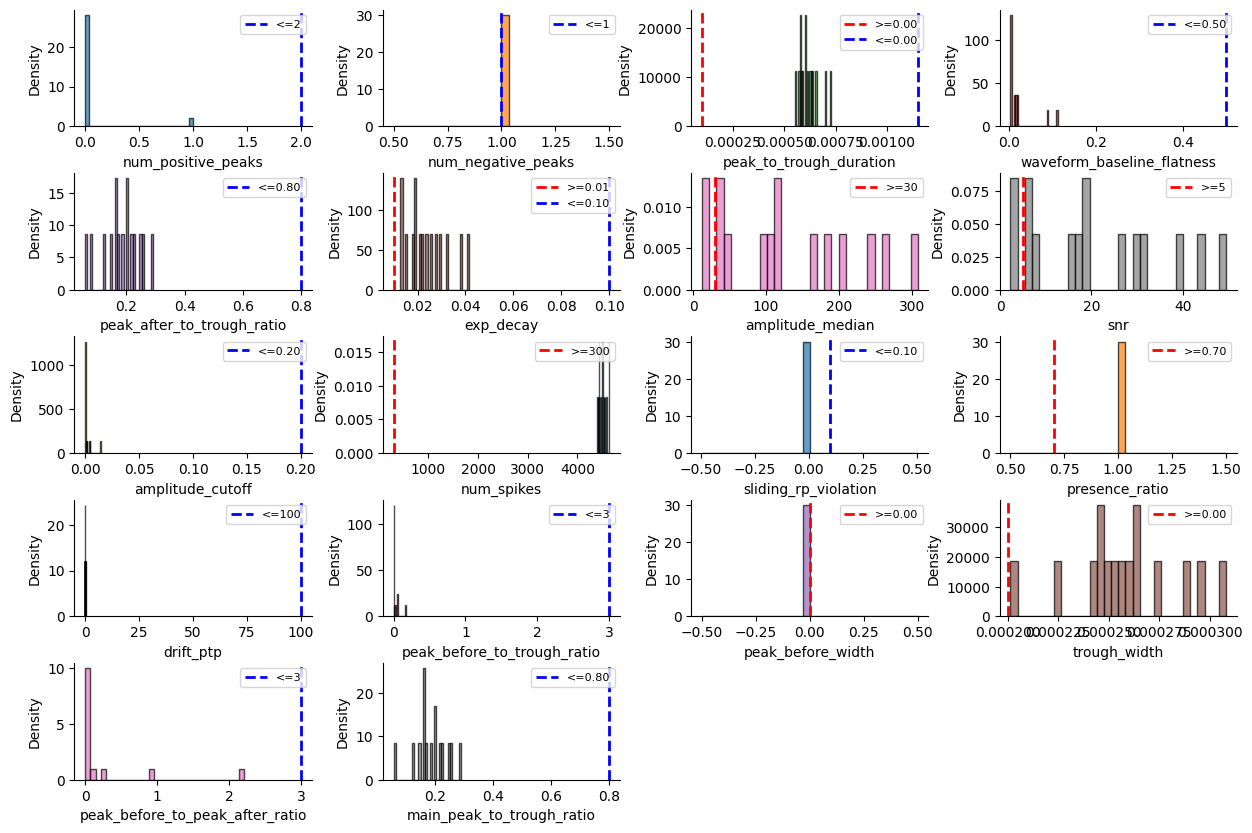

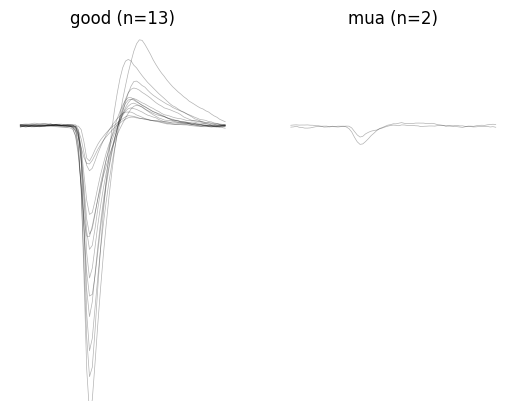

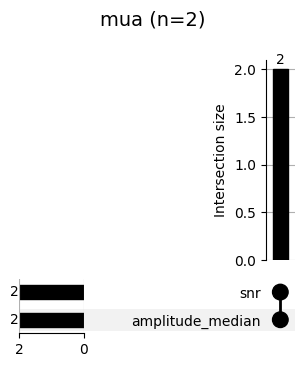

In [5]:
output_folder = Path("bombcell_si_demo_output")

labels, metrics, figures = bombcell.run_bombcell_qc(
    sorting_analyzer=analyzer,
    output_folder=output_folder,
    params=qc_params,
    thresholds=thresholds,
    n_jobs=1,
    progress_bar=False,
)

## Results

In [6]:
print(f"{metrics.shape[0]} units x {metrics.shape[1]} metrics\n")
print(labels["bombcell_label"].value_counts().to_string())

good_units = labels[labels["bombcell_label"] == "good"].index.tolist()
mua_units = labels[labels["bombcell_label"] == "mua"].index.tolist()
noise_units = labels[labels["bombcell_label"] == "noise"].index.tolist()

print(f"\ngood  ({len(good_units)}): {good_units}")
print(f"mua   ({len(mua_units)}): {mua_units}")
print(f"noise ({len(noise_units)}): {noise_units}")

15 units x 30 metrics

bombcell_label
good    13
mua      2

good  (13): ['0', '1', '3', '4', '5', '7', '8', '9', '10', '11', '12', '13', '14']
mua   (2): ['2', '6']
noise (0): []


In [7]:
sorted(p.name for p in output_folder.iterdir())

['bombcell_config.json',
 'labeling_results_narrow.csv',
 'labeling_results_wide.csv',
 'metric_histograms.png',
 'thresholds.json',
 'upset_plot_0.png',
 'waveforms_by_label.png']

## Figures

The pipeline returns the figures it made, and saves them alongside the CSVs. Metric histograms
with the thresholds drawn on:

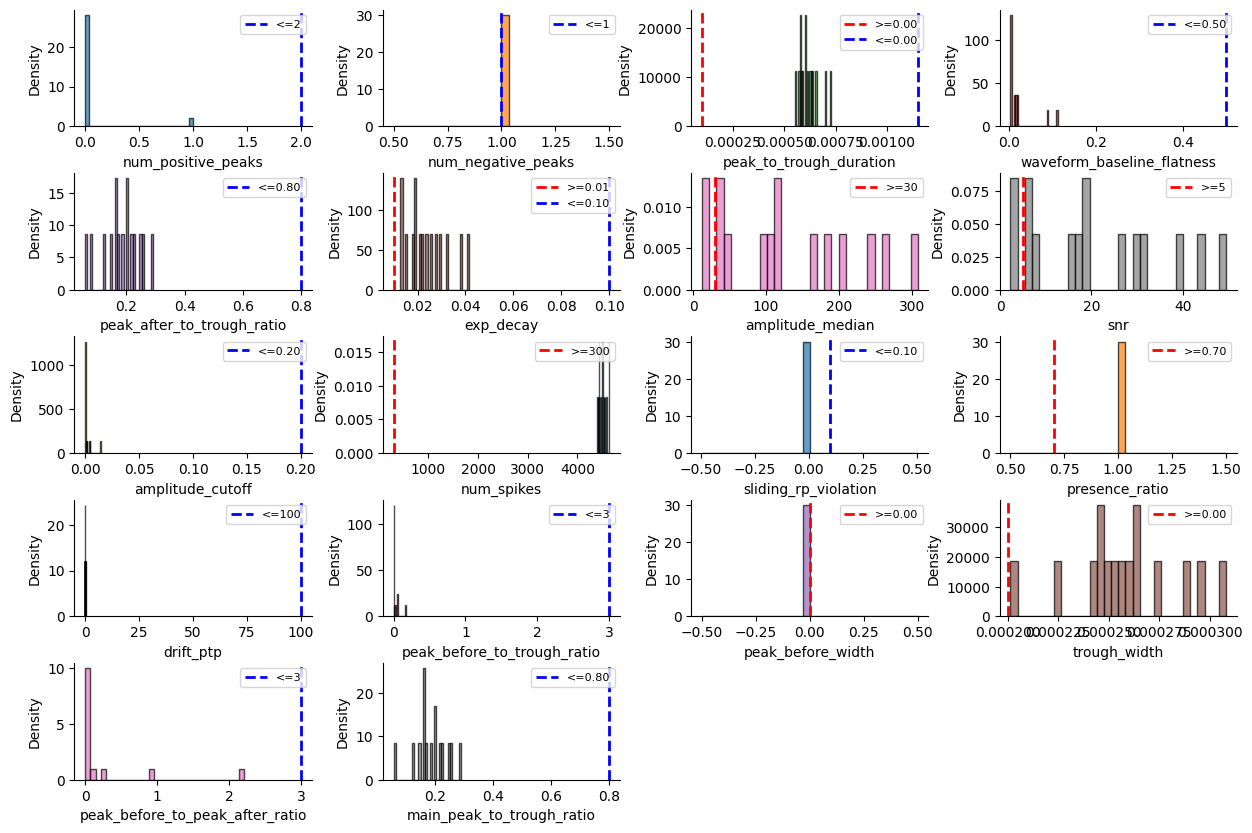

In [8]:
figures["histograms"]

Waveforms grouped by label:

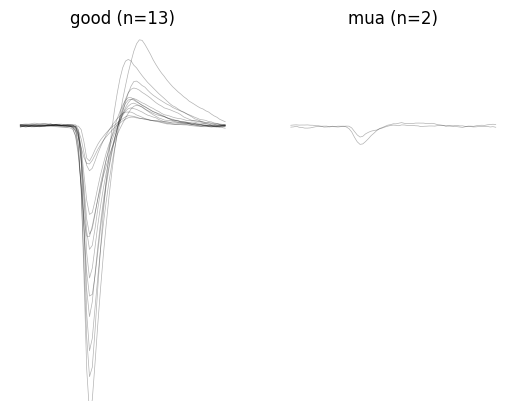

In [9]:
figures["waveforms"]

The UpSet plot shows *which combinations* of metrics units failed on, which is the quickest way
to see whether one over-strict threshold is doing all the work:

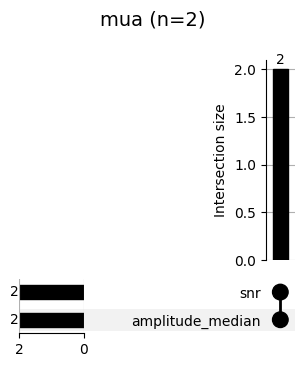

In [10]:
figures["upset"][0] if figures.get("upset") else "no upset plot (a single metric explained every failure)"

You can also plot the labeled waveforms directly from the analyzer:

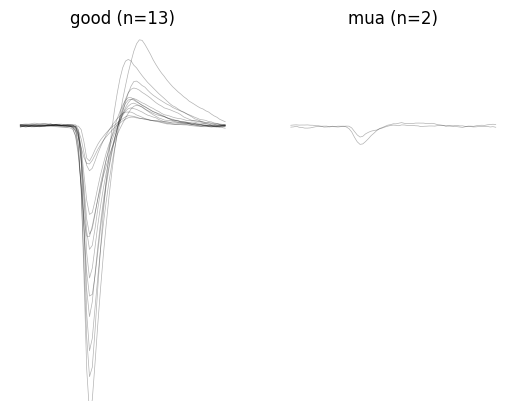

In [11]:
_ = sw.plot_unit_labels(analyzer, labels["bombcell_label"], ylims=(-300, 100))

## Using the labeler on its own

`bombcell_label_units` applies thresholds to metrics and nothing else - no computation, no
plotting, no saving. Use it when you have already computed what you need, or when your metrics
come from somewhere other than an analyzer.

In [12]:
labels_direct = sc.bombcell_label_units(
    sorting_analyzer=analyzer,
    thresholds=thresholds,
)
print((labels_direct["bombcell_label"] == labels["bombcell_label"]).all(), "- same labels as the pipeline")

True - same labels as the pipeline


/Users/jf5479/Dropbox/Python/spikeinterface/src/spikeinterface/curation/bombcell_curation.py:278: UserWarning: These metrics have not been computed, so their thresholds are ignored and units are labeled using the remaining ones: isolation_distance, l_ratio (from the 'mua' thresholds). isolation_distance and l_ratio come from the 'principal_components' extension, which is not computed by default. Compute them and re-run to include them, or remove them from the thresholds.
  warnings.warn(


It also takes a plain DataFrame of metrics, indexed by unit id:

```python
import pandas as pd
my_metrics = pd.read_csv("my_metrics.csv", index_col=0)
labels_direct = bombcell_label_units(external_metrics=my_metrics, thresholds=thresholds)
```

Because it computes nothing, valid-periods-aware labels need the metrics prepared first - see
below.

## Valid time periods

Valid periods are the stretches of a recording where a unit has stable amplitude and few
refractory violations. Computing metrics on those stretches only gives a fairer picture of units
that drift or drop out partway through.

**Option A - let the pipeline do it:**

```python
qc_params["compute_valid_periods"] = True
labels, metrics, figures = bombcell.run_bombcell_qc(analyzer, params=qc_params)
```

**Option B - compute them yourself first** (better when you want to tune the criteria, and makes
"what was the fp threshold?" unambiguous):

```python
analyzer.compute("amplitude_scalings")
analyzer.compute(
    "valid_unit_periods",
    fp_threshold=0.1,   # match your bombcell RPV threshold
    fn_threshold=0.1,   # match your bombcell amplitude_cutoff threshold
    period_duration_s_absolute=30.0,
    period_target_num_spikes=300,
    period_mode="absolute",
    minimum_valid_period_duration=180,
)
qc_params["compute_valid_periods"] = True
```

The pipeline reuses an existing `valid_unit_periods` extension as-is, and warns if its fp/fn
thresholds disagree with your BombCell thresholds. Afterwards the periods live on the analyzer:
`analyzer.get_extension("valid_unit_periods").get_data()`.

## Tuning by recording type

**Chronic** — stable recordings make the distance metrics reliable, so set
`compute_distance_metrics = True`. Drift is usually minimal and less informative.

**Acute** — drift artificially lowers `isolation_distance` and `l_ratio`, so leave
`compute_distance_metrics = False` (the default) and keep the drift threshold strict.

**Cerebellum** — complex spikes can trip the noise detector; relax `num_positive_peaks`.

**Striatum** — MSNs fire sparsely, so lower the spike-count and presence-ratio thresholds.